# Inferencia difusa

Tras ver cómo se modelan las variables difusas para representar conocimiento inexacto, vemos cómo se utilizan para implementar el proceso de inferencia.

## Modelo

El modelo de inferencia difusa sigue el mismo esquema para la definición de las reglas:

$$\text{IF } (PRECEDENT) \text{ THEN } (CONSEQUENT)$$

donde el precedente será **una etiqueta** de variable difusa o **un conjunto de ellas**, y el consecuente será **una etiqueta** de una variable difusa, con ciertas variaciones en función del método de inferencia en particular. 

Por ejemeplo:

$$\text{IF } (temp \text{ IS } high) \text{ THEN } (fan \text{ IS } max\_speed)$$
$$\text{IF } ((temp \text{ IS } low) \text{ AND } (hum \text{ IS } low)) \text{ THEN } (fan \text{ IS } min\_speed)$$


El proceso de inferencia difusa sigue los siguientes pasos:

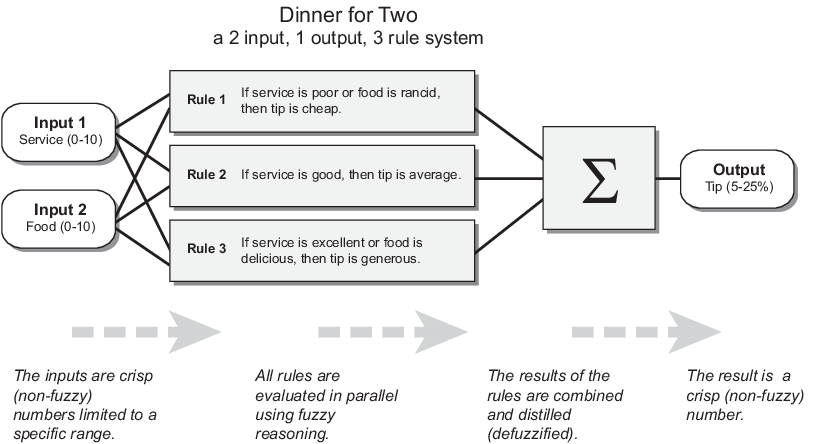

1. ***Fuzzificación* de los datos de entrada**: se toman los valores del dominio $\mathcal{D}$ y se inicializan las variables difusas correspondientes.

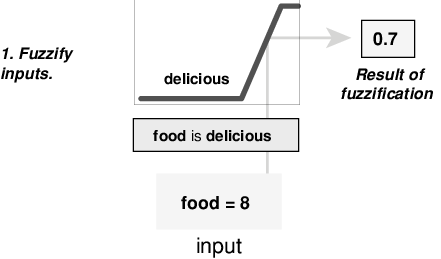

2. **Evaluación del precedente**: por cada regla, se evalúa el precedente para obtener el valor del precedente.

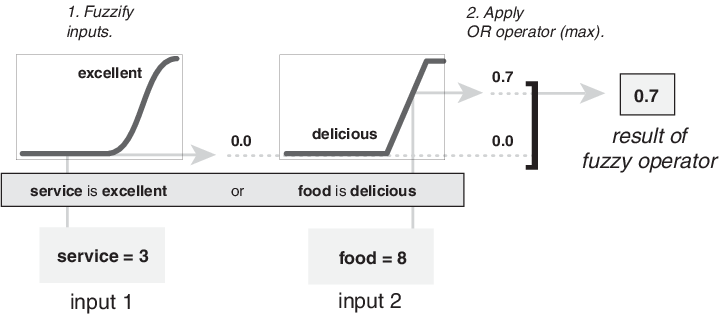

3. **Implicación**: por cada regla, se calcula el valor de la etiqueta de salida.

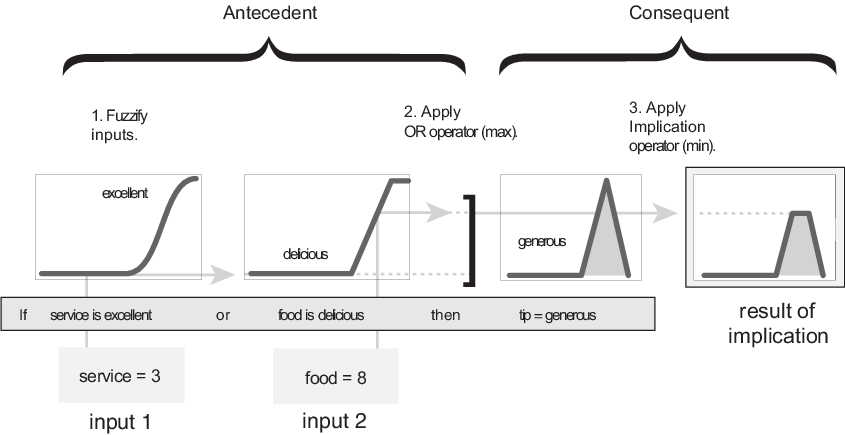

4. **Agregación**: se agregan los valores de las etiquetas de salida, reconstruyendo la variable difusa.

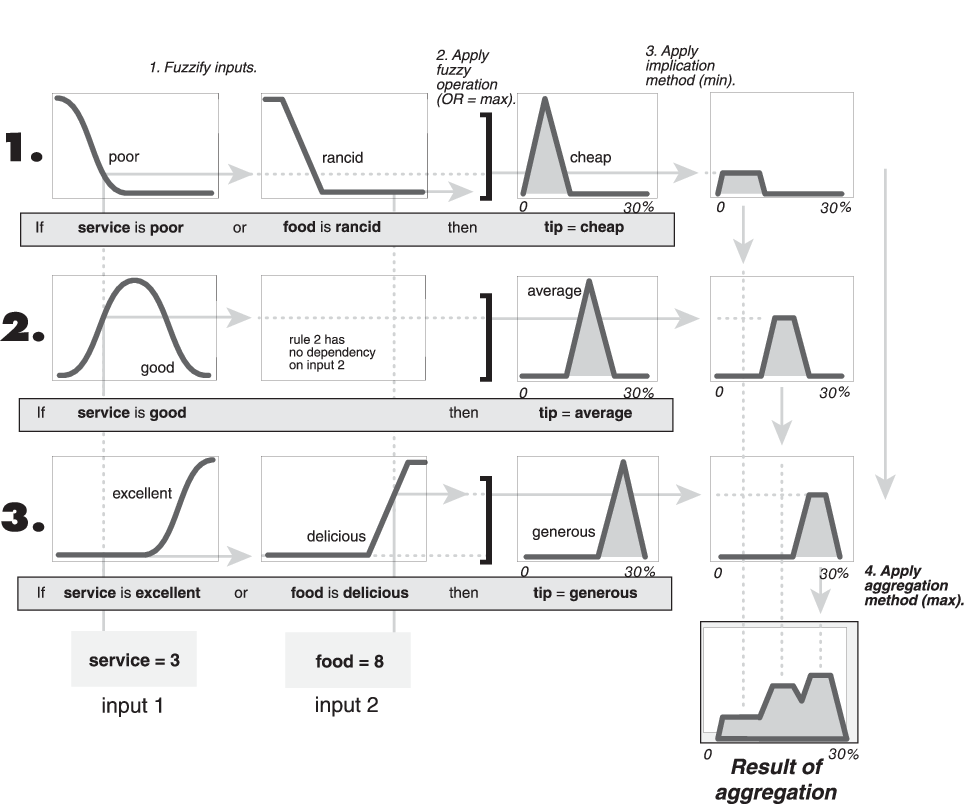

5. ***Defuzzificación* de la variable de salida**: con la agregación, se obtiene un valor real del dominio de salida.

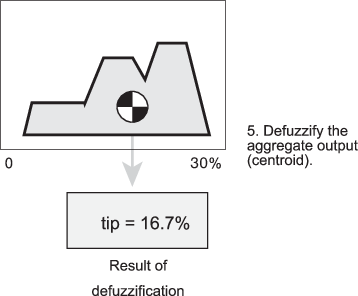

Poniéndolo todo junto, se obtiene el proceso de inferencia difuso **Mamdani**:

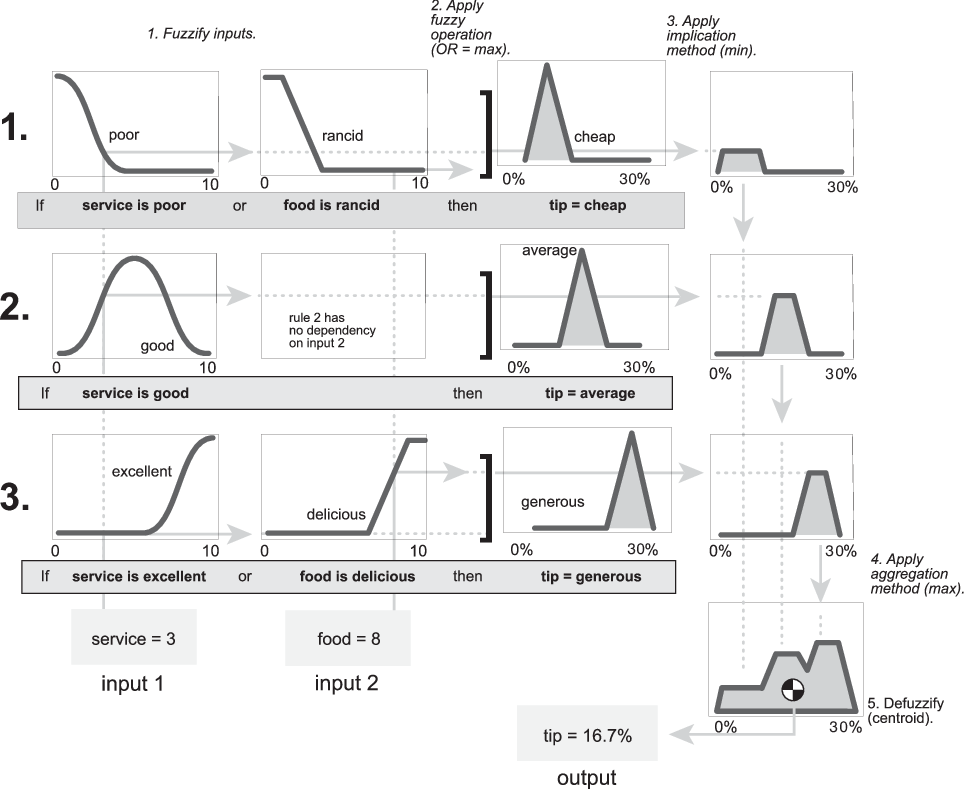

Existen otros métodos de *defuzzificación* que no hacen uso del centroide, y por lo tanto son más eficientes a nivel computacional. En concreto, existe uno que en lugar de tener etiquetas para la salida con funciones de activación, tiene **constantes** que se multiplican por el peso de activación del precedente de la regla, conocido como **Sugeno**:

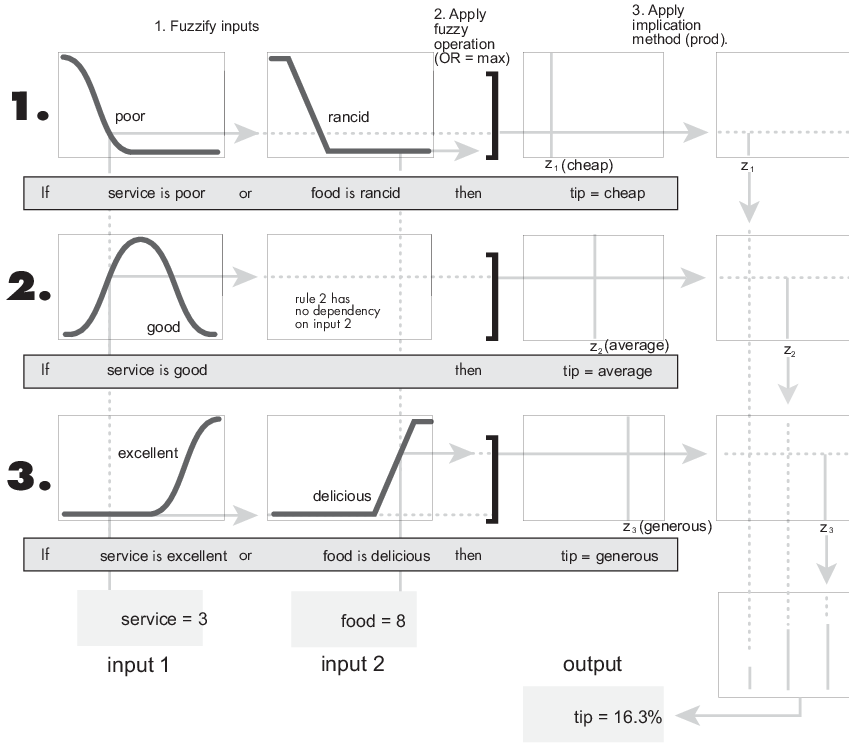

Para este método se contemplan los siguientes elementos:

* $w_i$: valor del precedente de la regla $i$
* $z_n$: constante asociada a la etiqueta $n$ de la variable de salida
* $\frac{\sum\limits_{i=0}^{N-1}w_i z_i}{\sum\limits_{i=0}^{N-1}w_i}$: valor final *defuzzificado*

#### Ejercicio 1

Completa el siguiente código para implementar la inferencia de Sugeno con el ejemplo del restaurante. Utiliza las conectivas lógicas de mínimo (AND) y máximo (OR).

In [1]:
def triangular_mf(x, a, b, c):
    return max(min((x - a) / (b - a + 1e-9), (c - x) / (c - b + 1e-9)), 0)


def service_mf(x):
    return {
        "poor": triangular_mf(x, 0, 0, 5),
        "average": triangular_mf(x, 0, 5, 10),
        "excellent": triangular_mf(x, 5, 10, 10),
    }


def food_mf(x):
    return {
        "rancid": triangular_mf(x, 0, 0, 5),
        "average": triangular_mf(x, 0, 5, 10),
        "delicious": triangular_mf(x, 5, 10, 10),
    }


tip_mf = {"cheap": 5, "average": 10, "generous": 30}


def sugeno_inference(service_val, food_val):
    service_fuzzy = service_mf(service_val)
    food_fuzzy = food_mf(food_val)

    numerator = 0
    denominator = 0

    # R1: If the service is poor or the food is rancid, then tip is cheap.
    w1 = max(service_fuzzy["poor"], food_fuzzy["rancid"])
    z1 = tip_mf["cheap"]
    numerator += w1 * z1
    denominator += w1

    # R2: If the service is good, then tip is average.
    w2 = service_fuzzy["average"]
    z2 = tip_mf["average"]
    numerator += w2 * z2
    denominator += w2

    # R3: If the service is excellent or the food is delicious, then tip is generous.
    w3 = max(service_fuzzy["excellent"], food_fuzzy["delicious"])
    z3 = tip_mf["generous"]
    numerator += w3 * z3
    denominator += w3

    return numerator / denominator if denominator != 0 else 0


service = 3
food = 8

print(
    f"Tip for service={service} and food={food} is {sugeno_inference(service, food)}% (expected 16.25%)"
)

Tip for service=3 and food=8 is 16.25% (expected 16.25%)
